In [2]:
#1_Data Loading and Inspection

import pandas as pd

# Load dataset
df = pd.read_csv('E:\Bitsom\Assignment\Machine Learning\data\q1_heart_disease.csv')

# Shape
print("Shape:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# First 5 rows
df.head()

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


<>:6: SyntaxWarning: invalid escape sequence '\B'
<>:6: SyntaxWarning: invalid escape sequence '\B'
C:\Users\shiva\AppData\Local\Temp\ipykernel_31392\396914524.py:6: SyntaxWarning: invalid escape sequence '\B'
  df = pd.read_csv('E:\Bitsom\Assignment\Machine Learning\data\q1_heart_disease.csv')


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


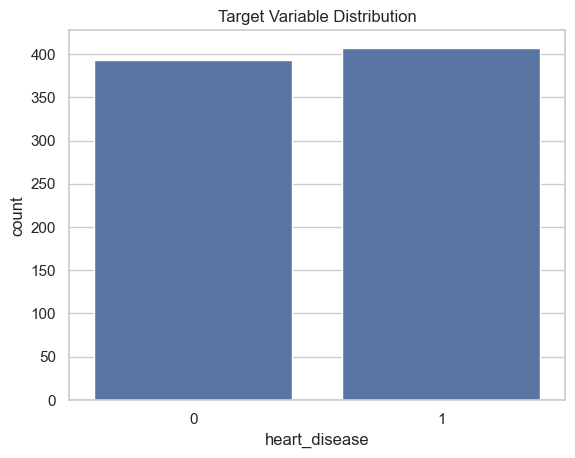

In [3]:
#2_Exploratory Data Analysis_Target Distribution

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

sns.countplot(x='heart_disease', data=df)
plt.title("Target Variable Distribution")
plt.show()


## Interpretation:

The target variable distribution shows that the dataset is approximately balanced, with a similar number of patients having heart disease (1) and not having heart disease (0).

This is beneficial for model training because:
- It reduces the risk of bias toward a dominant class
- Evaluation metrics such as accuracy, precision, and recall will be more reliable

Since there is no significant class imbalance, techniques like resampling are not required. 
This balanced distribution ensures that model performance reflects true predictive capability rather than class dominance.

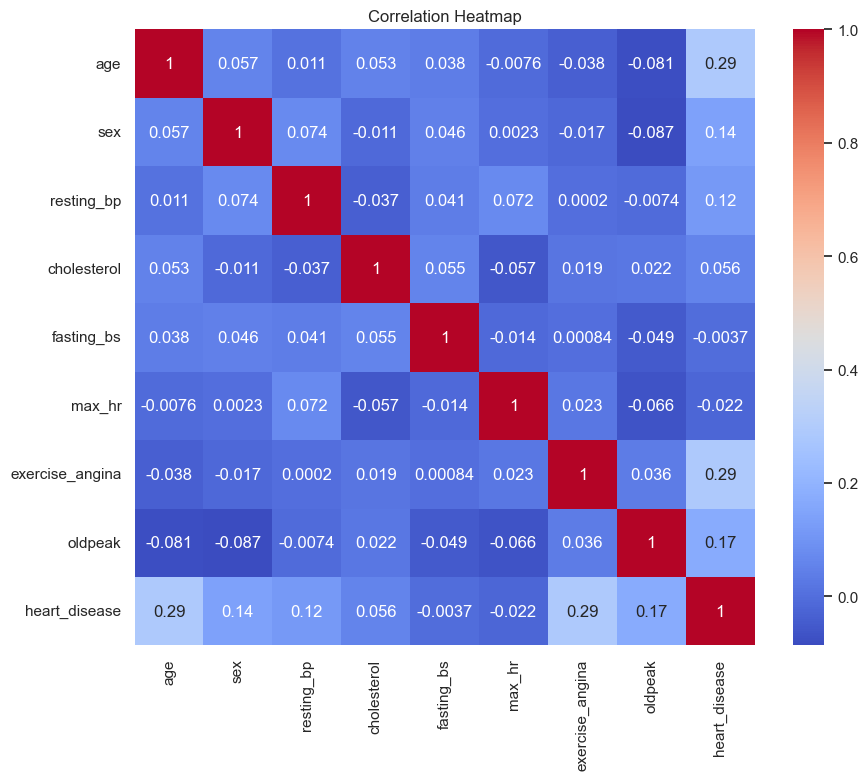

In [4]:
#2_Exploratory Data Analysis_Correlation Heatmap

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Interpretation:

The correlation heatmap shows the relationships between numerical features and the target variable (heart_disease).

Key observations:

- Age(0.29) and exercise_angina (0.29) have the strongest positive correlation with heart disease, indicating that older patients and those experiencing exercise-induced angina are more likely to have heart disease.
- Oldpeak (0.17) and sex (0.14) also show moderate positive correlations, suggesting some influence on the target variable.
- Features like cholesterol (0.056), fasting_bs (-0.0037), and max_hr (-0.022) show very weak or negligible correlation with heart disease, implying limited predictive power individually.
- Most feature-to-feature correlations are low, indicating low multicollinearity, which is beneficial for model stability.

## Conclusion:
Heart disease prediction appears to depend on a combination of features rather than a single dominant variable. Features like age and exercise-induced angina are likely to be important predictors in the model.

In [5]:
## 3. Data Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Separate features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# One-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (640, 15)
Test shape: (160, 15)


C:\Users\shiva\AppData\Local\Temp\ipykernel_31392\3274450301.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [6]:
## 4. Model Training

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [7]:
## 5. Model Evaluation

from sklearn.metrics import confusion_matrix, classification_report

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Decision Tree
Confusion Matrix:
 [[56 23]
 [25 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
  

## Model Evaluation and Comparison

### Decision Tree:
- Accuracy: 70%
- F1-score: 0.70 (both classes)
- The model shows balanced precision and recall but overall performance is moderate.
- It likely suffers from overfitting due to its simple structure.

### Random Forest:
- Accuracy: 77%
- F1-score: ~0.79–0.80 across classes
- Higher precision and recall compared to Decision Tree
- Better generalization due to ensemble learning

### Key Comparison:
- Random Forest reduces both false positives and false negatives (as seen in the confusion matrix)
- It improves recall for class 1 (heart disease), which is critical in a medical context

### Best Model:
**Random Forest is the best-performing model** because:
- It has higher F1-score across both classes
- It provides a better balance between precision and recall
- It generalizes better than Decision Tree

### Conclusion:
Random Forest is preferred for this problem as it improves detection of heart disease cases while maintaining strong overall performance.

In [8]:
## 6. Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='f1')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [9]:
## Evaluate Tuned Model

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Tuned Model Performance:")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Tuned Model Performance:
[[61 18]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



## Hyperparameter Tuning Analysis

The best parameters obtained from GridSearchCV are:
- n_estimators = 100
- max_depth = None

### Comparison: Tuned vs Untuned Model

- Untuned Random Forest Accuracy: ~0.77  
- Tuned Random Forest Accuracy: ~0.79  

- F1-score improved slightly from ~0.77 to ~0.79

### Interpretation:

The tuned model shows a **marginal improvement in performance**, particularly in F1-score. However, the optimal parameters identified are close to the default values, indicating that:

- The baseline model was already well-optimized for this dataset
- The dataset may not require deep hyperparameter tuning
- Model performance is more dependent on data quality and feature relationships

### Conclusion:

Hyperparameter tuning resulted in a **minor performance gain**, but not a significant improvement. This suggests that Random Forest is inherently robust for this problem and performs well even with default settings.